# 2.1 Entraînement d'un classeur binaire et multi-classes pour la vente en ligne avec scikit-learn

In [30]:
# Chargement des modules
import pandas as pd
import numpy as np
from time import *
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
# Pour masquer les warnings
import warnings
from pandas.errors import ChainedAssignmentError
warnings.filterwarnings("ignore", category=ChainedAssignmentError)

In [2]:
# Chargement des données
data = pd.read_csv("Customer.csv", na_values=['?', 'unknown'])
data['first_item_prize'] = pd.to_numeric(data['first_item_prize'], errors='coerce')
data['revenue'] = pd.to_numeric(data['revenue'], errors='coerce')
data.dropna(inplace=True)


In [3]:
data.head()

,age,pages,first_item_prize,gender,ReBuy,News_click,country,revenue
0,41.0,6.0,28.0,Fem,False,4.0,China,113.0
1,34.0,4.0,15.5,Fem,True,2.0,China,36.0
3,20.0,1.0,44.0,Fem,False,2.0,China,71.0
4,39.0,10.0,10.0,Fem,True,4.0,China,80.0
6,36.0,6.0,44.0,Masc,False,2.0,China,51.0


In [4]:
data.info()

<class 'pandas.DataFrame'>
Index: 9993 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               9993 non-null   float64
 1   pages             9993 non-null   float64
 2   first_item_prize  9993 non-null   float64
 3   gender            9993 non-null   str    
 4   ReBuy             9993 non-null   bool   
 5   News_click        9993 non-null   float64
 6   country           9993 non-null   str    
 7   revenue           9993 non-null   float64
dtypes: bool(1), float64(5), str(2)
memory usage: 634.3 KB


In [5]:
# Prétraitement
data['gender'] = LabelEncoder().fit_transform(data['gender'])
data['ReBuy'] = data['ReBuy'].astype(int)
data['country'] = LabelEncoder().fit_transform(data['country'])

In [6]:
data.head()

,age,pages,first_item_prize,gender,ReBuy,News_click,country,revenue
0,41.0,6.0,28.0,0,0,4.0,8,113.0
1,34.0,4.0,15.5,0,1,2.0,8,36.0
3,20.0,1.0,44.0,0,0,2.0,8,71.0
4,39.0,10.0,10.0,0,1,4.0,8,80.0
6,36.0,6.0,44.0,1,0,2.0,8,51.0


In [7]:
data.info()

<class 'pandas.DataFrame'>
Index: 9993 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               9993 non-null   float64
 1   pages             9993 non-null   float64
 2   first_item_prize  9993 non-null   float64
 3   gender            9993 non-null   int64  
 4   ReBuy             9993 non-null   int64  
 5   News_click        9993 non-null   float64
 6   country           9993 non-null   int64  
 7   revenue           9993 non-null   float64
dtypes: float64(5), int64(3)
memory usage: 702.6 KB


## 2.1.1 Classeur binaire 

### a) Entraînement et test par la validation croisée avec k=3

### b) Mesure des métriques de précision, rappel et F1-Mesure

In [8]:
# Transformer la variable cible en binaire
moyenne_revenue = data['revenue'].mean()
data['revenue_binaire'] = (data['revenue'] > moyenne_revenue).astype(int)

In [9]:
# Séparation des prédicteurs de la variable cible
X = data.drop(columns=['revenue','revenue_binaire'])
y = data['revenue_binaire']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [10]:
# Standardisation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Sélection d'un modèle: architecture du PMC

EXIGENCES GENERIQUES

* le nombre de couches cachées ne doit pas dépasser 5 couches 
* nombre de neurones par couche cachée doit être compris entre 10 et 100 neurones
* Architecture doit être la plus performante en terme d'exactitude

* fonction d'activation des neurones des couches cachées et de la couche de sortie restent à être déterminer par moi


###  Modèle de base avec validation croisée

* utilisation de 2 couches cachées. La première est composé de 50.
* La fonction d'activation de la sortie est une logistique
* La fonction d'activation de la couche cachée est relu
* la regle d'apprentissage est la descente du gradient: solver =adam 

In [11]:
clf = MLPClassifier(hidden_layer_sizes=(50,), solver='adam', max_iter=2000, activation='relu', random_state=1)
#mesure du temps courant
tc = time()

clf.fit(X_train, y_train)
tt = time()
print("le temps d'entrainement en secondes {:.2f}".format(tt-tc))
y_pred_cv = cross_val_predict(clf, X_train, y_train, cv=3)
print("\nRapport de classification - Validation croisée")
print(classification_report(y_train, y_pred_cv))

le temps d'entrainement en secondes 8.52

Rapport de classification - Validation croisée
              precision    recall  f1-score   support

           0       0.78      0.81      0.80      4871
           1       0.69      0.65      0.67      3123

    accuracy                           0.75      7994
   macro avg       0.74      0.73      0.73      7994
weighted avg       0.75      0.75      0.75      7994



### c) Le modèle surajuste ou sousajuste? 

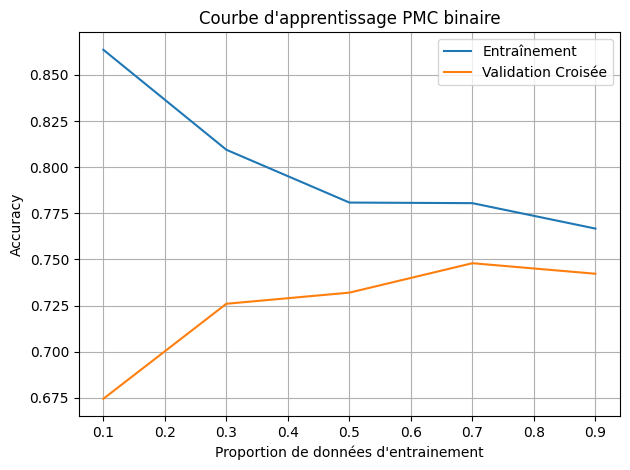

In [49]:
# Courbe d'apprentissage

warnings.filterwarnings('ignore')

train_sizes = np.linspace(0.1, 0.9, 5)
train_scores, val_scores = [], []
for frac in train_sizes:
    X_part, _, y_part, _ = train_test_split(X_train, y_train, train_size=frac, random_state=42)
    clf.fit(X_part, y_part)
    train_scores.append(clf.score(X_part, y_part))
    val_scores.append(np.mean(cross_val_score(clf, X_part, y_part, cv=3)))

plt.plot(train_sizes, train_scores, label= 'Entraînement')
plt.plot(train_sizes, val_scores, label = 'Validation Croisée')
plt.xlabel("Proportion de données d'entrainement")
plt.ylabel("Accuracy")
plt.title("Courbe d'apprentissage PMC binaire")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Interprétations**:

La **courbe rouge (modèle avec le jeu d'entraînement)** commence avec une exactitude de **85%** avec peu de données. On observe une diminution extrême de l'exactitude à mesure qu'on augmente de données.


La **courbe bleue (modèle avec le jeu de validation)** commence avec une exactitude plus basse de **67.5%** avec peu de données. Mais cette exactitude augmente au fur et à mesure qu'on augmente de données.


On est dans un cas de **sur-apprentissage**, avec un jeu d'entraînement ayant une exactitude très élevé de **85%** et un jeu de test ayant une exactitude très basse de **67.5%**. On observe également un grand écart significatif entre les 2 courbes.

### d) Optimisation des hyperparamètres

In [25]:
# Définition de la grille d'hyperparamètre
param_dist = {
    'hidden_layer_sizes': [
        (50,), (100,),
        (100,50), (100,75)
    ],
    'activation': ['tanh', 'relu'],
    'solver': ['adam', 'sgd'],
    'alpha': [0, 1e-5, 1],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'max_iter': [2000]
}

random_search = RandomizedSearchCV(MLPClassifier(random_state=1), param_distributions=param_dist, n_iter=20, cv=3, n_jobs=-1, random_state=1)
random_search.fit(X_train, y_train)

print("\nMeilleurs hyperparamètres:")
print(random_search.best_params_)


Meilleurs hyperparamètres:
{'solver': 'sgd', 'max_iter': 2000, 'learning_rate_init': 0.01, 'hidden_layer_sizes': (100,), 'alpha': 1e-05, 'activation': 'tanh'}


### e) Test du meilleur modèle avec un jeu de test et mesure des différentes métriques de précision, rappel et F1-Mesure


Rapport de classification
              precision    recall  f1-score   support

           0       0.78      0.83      0.81      1229
           1       0.70      0.63      0.67       770

    accuracy                           0.76      1999
   macro avg       0.74      0.73      0.74      1999
weighted avg       0.75      0.76      0.75      1999



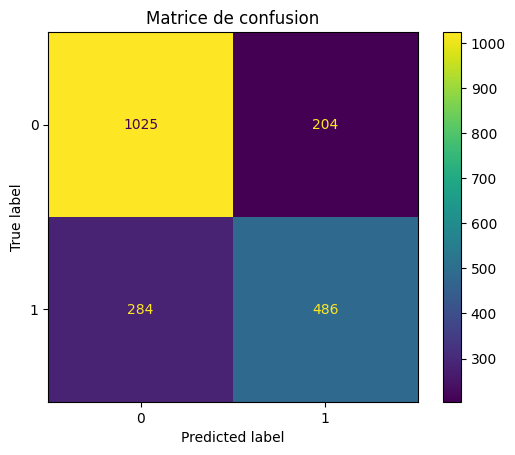

In [31]:
best_model = random_search.best_estimator_
y_test_pred = best_model.predict(X_test)
print("\nRapport de classification")
print(classification_report(y_test, y_test_pred))
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Matrice de confusion")
plt.show()

### f)Comparaison des résultats obtenus avec ce modèle et celui obtenu dans le devoir #2

In [51]:
# Création d'un tableau comparatif

# Les métriques choisis représentent average weighted afin de prendre en compte des deux classes proportionnellement.
data = {
    "Métriques": ["Accuracy - Train", "Accuracy - Test", "Précision", "Rappel", "F1-score"],
    "Arbre de décision": [ 0.92, 0.86, 0.88, 0.88, 0.89],
    "Perceptron Multi-Couches (PMC)": [ 0.76, 0.75, 0.75, 0.76 , 0.75]
}

df = pd.DataFrame(data)
df = df.set_index("Métriques")
display(df)

,Arbre de décision,Perceptron Multi-Couches (PMC)
Métriques,,
Accuracy - Train,0.92,0.76
Accuracy - Test,0.86,0.75
Précision,0.88,0.75
Rappel,0.88,0.76
F1-score,0.89,0.75


Au départ, nous avions un **sur-apprentissage** avec le modèle d'**Arbre de Décision** avec un niveau d'exactitude de **92%** pour les **données d'entraînement** et un niveau d'exactitude de **86%** pour les **données de validation**.

On peut constater que le modèle de **perceptron multi-couche** donne de **bons résultats** sur les **données d'entraînement** avec un niveau d'exactitude de **76%**. On observe la même chose sur les **données de validation** avec un niveau d'exactitude de **75%**. On peut en conclure un **faible écart**. Le modèle **généralise bien**.

